In [145]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
import tensorflow as tf
from tensorflow import keras
np.random.seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


In [146]:
CSV_PATH = Path("../csv/merged_ML_ch2-600to800.csv")

# stage-1 artifacts
S1_DIR    = Path("models_stage1_unmatched_vs_matched")
S1_MODEL  = S1_DIR / "stage1_unmatched_vs_matched_dnn_best.keras"
S1_PREP   = S1_DIR / "stage1_preprocess.joblib"     # bare sklearn Pipeline

# stage-2 artifacts
S2_DIR    = Path("models_stage2_qqbar_binary")
S2_MODEL  = S2_DIR / "qqbar_binary_dnn_best.keras"
S2_PREP   = S2_DIR / "qqbar_binary_preprocessor.joblib"   # dict: imputer/scaler/features

OUTPUT_DIR = Path("outputs_twostage_600to800")
OUTPUT_DIR.mkdir(exist_ok=True)

STAGE1_THRESHOLD = 0.85  # keep jets with matched-score > this

for p in [CSV_PATH, S1_MODEL, S1_PREP, S2_MODEL, S2_PREP]:
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p.resolve()}")
print("All artifacts found.")

All artifacts found.


In [147]:
def engineer_stage1(df):
    """Exact stage-1 engineering (includes deltaR34 log-transform)."""
    df = df.copy()
    for col in ["pt_dispersion3", "pt_dispersion4"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))
    if "kt2" in df.columns:
        df["kt2"] = np.log1p(df["kt2"].clip(lower=0))
    if "deltaR34" in df.columns:
        dr = df["deltaR34"].clip(lower=1e-4)
        df["deltaR34"] = np.log1p(1.0 / dr)
    df["z_sum"]=df["z1"]+df["z2"]; df["z_absdiff"]=np.abs(df["z1"]-df["z2"])
    df["z_min"]=np.minimum(df["z1"],df["z2"]); df["z_max"]=np.maximum(df["z1"],df["z2"])
    df["z_minmax_ratio"]=df["z_min"]/(df["z_max"]+1e-8)
    for c3,c4,name in [("N_charged3","N_charged4","N_charged"),("N_all3","N_all4","N_all"),
                       ("pt_weight3","pt_weight4","pt_weight"),
                       ("pt_dispersion3","pt_dispersion4","pt_dispersion")]:
        if c3 in df.columns and c4 in df.columns:
            v3,v4=df[c3],df[c4]; vmin,vmax=np.minimum(v3,v4),np.maximum(v3,v4)
            df[f"{name}_sum"]=v3+v4; df[f"{name}_absdiff"]=np.abs(v3-v4)
            df[f"{name}_min"]=vmin; df[f"{name}_max"]=vmax
            df[f"{name}_minmax_ratio"]=vmin/(vmax+1e-8)
    return df

def engineer_stage2(df):
    """Exact stage-2 engineering (no deltaR34 transform)."""
    df = df.copy()
    for col in ["pt_dispersion3", "pt_dispersion4"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))
    if "kt2" in df.columns:
        df["kt2"] = np.log1p(df["kt2"].clip(lower=0))
    df["z_sum"]=df["z1"]+df["z2"]; df["z_absdiff"]=np.abs(df["z1"]-df["z2"])
    df["z_min"]=np.minimum(df["z1"],df["z2"]); df["z_max"]=np.maximum(df["z1"],df["z2"])
    df["z_minmax_ratio"]=df["z_min"]/(df["z_max"]+1e-8)
    for c3,c4,name in [("N_charged3","N_charged4","N_charged"),("N_all3","N_all4","N_all"),
                       ("pt_weight3","pt_weight4","pt_weight"),
                       ("pt_dispersion3","pt_dispersion4","pt_dispersion")]:
        if c3 in df.columns and c4 in df.columns:
            v3,v4=df[c3],df[c4]; vmin,vmax=np.minimum(v3,v4),np.maximum(v3,v4)
            df[f"{name}_sum"]=v3+v4; df[f"{name}_absdiff"]=np.abs(v3-v4)
            df[f"{name}_min"]=vmin; df[f"{name}_max"]=vmax
            df[f"{name}_minmax_ratio"]=vmin/(vmax+1e-8)
    return df

In [148]:
df0 = pd.read_csv(CSV_PATH)
print("Raw shape:", df0.shape)

ORIGINAL_TARGET = "channel2"
for req in [ORIGINAL_TARGET, "dpsi12"]:
    if req not in df0.columns:
        raise ValueError(f"CSV missing required column '{req}'")

# stage-1 was trained on channel2 in {0,1,2,3} (matched vs unmatched).
df0 = df0[df0[ORIGINAL_TARGET].isin([0,1,2,3])].copy().reset_index(drop=True)
df0["row_id"] = np.arange(len(df0))   # stable id to carry through both stages
print("Rows (channel2 in 0..3):", len(df0))

Raw shape: (5847342, 18)
Rows (channel2 in 0..3): 5793431


In [149]:
# --- stage-1 preprocessor (Pipeline) + model ---
prep1 = load(S1_PREP)

# Recover the EXACT feature names the pipeline was fit on.
# SimpleImputer stores them in feature_names_in_.
s1_features = list(prep1.named_steps["imputer"].feature_names_in_)
print("Stage-1 expects", len(s1_features), "features")

# Build stage-1 inputs from the RAW dataframe (stage-1 did NOT engineer features).
d1 = df0.copy()
missing = [c for c in s1_features if c not in d1.columns]
if missing:
    raise ValueError(f"Stage-1 features missing from CSV: {missing}")
X1 = d1[s1_features].replace([np.inf, -np.inf], np.nan)

X1_pp = prep1.transform(X1).astype("float32")

m1 = keras.models.load_model(S1_MODEL, compile=False)
pred1 = m1.predict(X1_pp, batch_size=4096, verbose=1)

matched_score = pred1[:, 1] if (pred1.ndim == 2 and pred1.shape[1] == 2) else pred1.ravel()
df0["stage1_matched_score"] = matched_score

keep_mask = matched_score > STAGE1_THRESHOLD
print(f"Stage-1: {keep_mask.sum():,} / {len(df0):,} jets pass matched-score > {STAGE1_THRESHOLD}")
df_matched = df0[keep_mask].copy().reset_index(drop=True)

true_matched = (df_matched["channel2"] != 0).mean()
print(f"Stage-1 selected sample is {true_matched:.3%} truly matched (channel2 != 0)")

Stage-1 expects 12 features
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Stage-1: 428,101 / 5,793,431 jets pass matched-score > 0.85
Stage-1 selected sample is 84.384% truly matched (channel2 != 0)


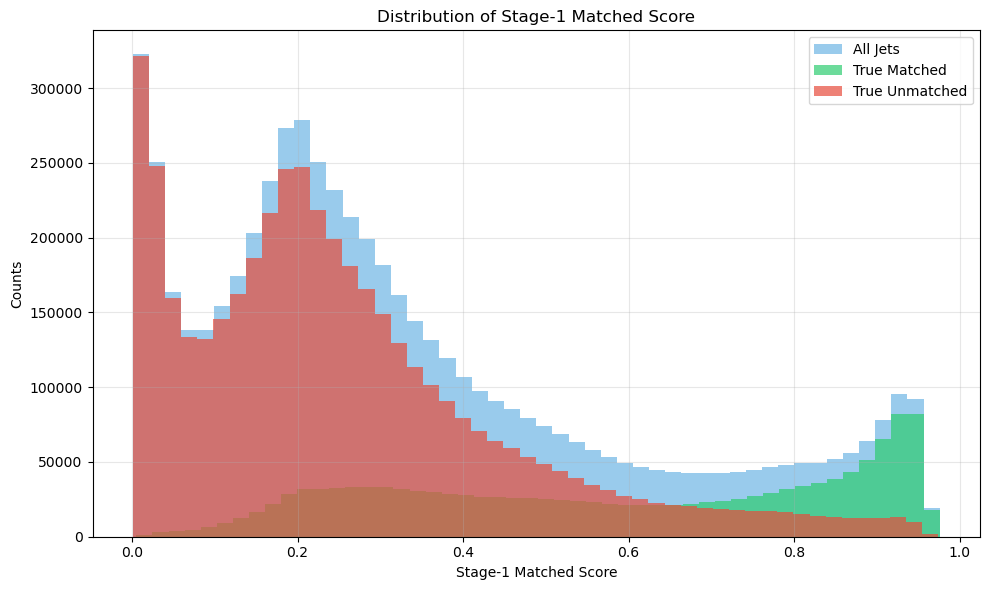

In [150]:
# Plot the distribution of stage1_matched_score for all, true matched, and true unmatched
plt.figure(figsize=(10, 6))

# All dataset
plt.hist(df0["stage1_matched_score"], bins=50, color="#3498db", alpha=0.5, label="All Jets")

# True matched (channel2 != 0)
plt.hist(df0[df0["channel2"] != 0]["stage1_matched_score"], bins=50, color="#2ecc71", alpha=0.7, label="True Matched")

# True unmatched (channel2 == 0)
plt.hist(df0[df0["channel2"] == 0]["stage1_matched_score"], bins=50, color="#e74c3c", alpha=0.7, label="True Unmatched")

# Add labels, legend, and title
plt.xlabel("Stage-1 Matched Score")
plt.ylabel("Counts")
plt.title("Distribution of Stage-1 Matched Score")
plt.legend()
plt.grid(alpha=0.3)

# Save and show the plot
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matched_score_vs_counts_all_true_matched_unmatched.png", dpi=150)
plt.show()

In [151]:
# stage-2 expects matched channels {1,2,3} and 0 because it passed 
df2 = df_matched[df_matched["channel2"].isin([0,1,2,3])].copy().reset_index(drop=True)
df2["is_qqbar"] = (df2["channel2"] == 1).astype(np.int64)
print("Jets into stage-2 (channel2 in 1..3 AND passed stage-1):", len(df2))

# stage-2 preprocessor bundle: dict with imputer/scaler/features
pp2 = load(S2_PREP)
imp2, scl2, feat2 = pp2["imputer"], pp2["scaler"], pp2["features"]

d2 = engineer_stage2(df2)
missing = [c for c in feat2 if c not in d2.columns]
if missing:
    raise ValueError(f"Stage-2 missing feature columns: {missing}")
X2 = d2[feat2]
X2_pp = scl2.transform(imp2.transform(X2)).astype("float32")

m2 = keras.models.load_model(S2_MODEL, compile=False)
df2["score"] = m2.predict(X2_pp, batch_size=4096, verbose=1).ravel()
print("Stage-2 score range:", df2['score'].min().round(3), "-", df2['score'].max().round(3))

Jets into stage-2 (channel2 in 1..3 AND passed stage-1): 428101
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Stage-2 score range: 0.117 - 0.73


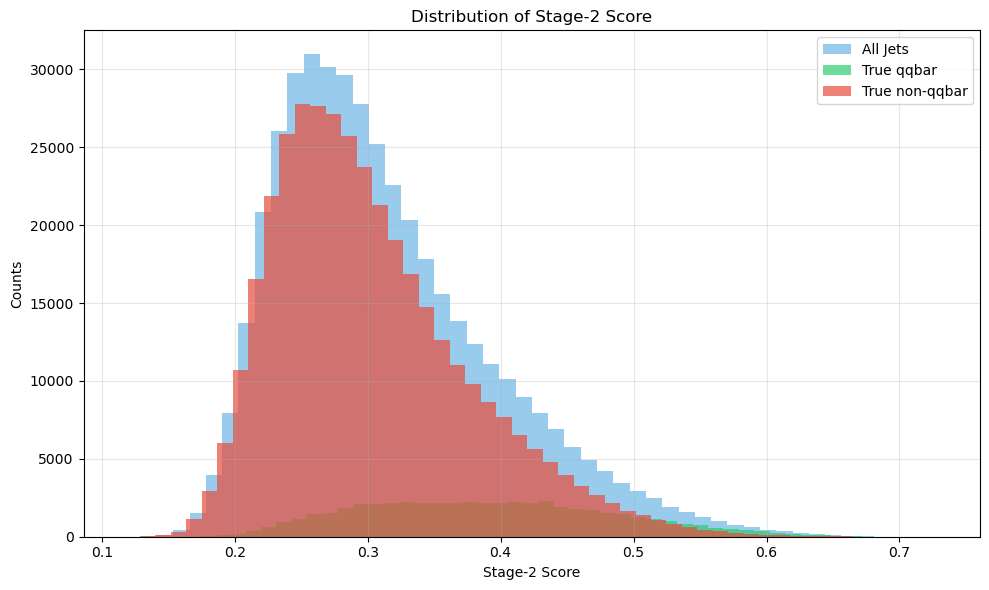

In [152]:
#Plot the distribution of score for all, true qqbar, and true non-qqbar
plt.figure(figsize=(10, 6))

# All dataset
plt.hist(df2["score"], bins=50, color="#3498db", alpha=0.5, label="All Jets")

# True qqbar (channel2 == 1)
plt.hist(df2[df2["channel2"] == 1]["score"], bins=50, color="#2ecc71", alpha=0.7, label="True qqbar")

# True non-qqbar (channel2 != 1)
plt.hist(df2[df2["channel2"] != 1]["score"], bins=50, color="#e74c3c", alpha=0.7, label="True non-qqbar")

# Add labels, legend, and title
plt.xlabel("Stage-2 Score")
plt.ylabel("Counts")
plt.title("Distribution of Stage-2 Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stage2_score_vs_counts_all_true_qqbar_nonqqbar.png", dpi=150)
plt.show()

In [153]:
y_true = df2["is_qqbar"].to_numpy()
dpsi   = df2["dpsi12"].to_numpy()
score  = df2["score"].to_numpy()
n_sig_total = int(y_true.sum())

thr_grid = np.linspace(0.3, 0.69, 20)
rows=[]
for thr in thr_grid:
    sel = score >= thr
    n = int(sel.sum())
    if n == 0:
        continue
    n_sig = int(y_true[sel].sum())
    cos2 = np.cos(2.0*dpsi[sel])
    rows.append(dict(threshold=thr, N=n,
                     purity=n_sig/n,
                     efficiency=(n_sig/n_sig_total if n_sig_total else 0.0),
                     cos2_mean=cos2.mean(),
                     cos2_err=cos2.std()/np.sqrt(n)))
res = pd.DataFrame(rows)
res.head(10)

,threshold,N,purity,efficiency,cos2_mean,cos2_err
0,0.300000,207001,0.204965,0.806601,-0.129195,0.001559
1,0.320526,166031,0.232944,0.735271,-0.133886,0.001739
2,0.341053,131819,0.263778,0.661033,-0.141316,0.001947
3,0.361579,104290,0.296270,0.587403,-0.146879,0.002186
4,0.382105,81843,0.330169,0.513716,-0.154377,0.002463
5,0.402632,63020,0.368264,0.441208,-0.161289,0.002804
6,0.423158,47322,0.408436,0.367445,-0.169189,0.003237
7,0.443684,34533,0.447224,0.293607,-0.179863,0.003785
8,0.464211,24845,0.491487,0.232144,-0.196169,0.004440
9,0.484737,17355,0.535638,0.176727,-0.207542,0.005286


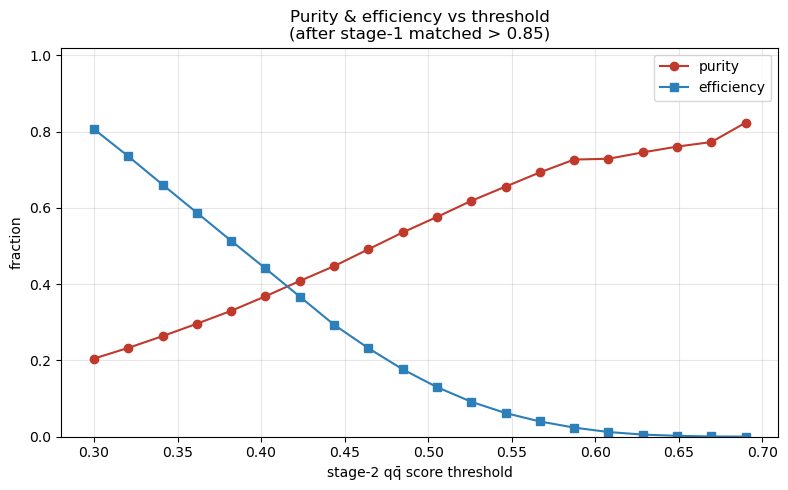

In [154]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(res["threshold"], res["purity"], "o-", color="#c0392b", label="purity")
ax.plot(res["threshold"], res["efficiency"], "s-", color="#2c7fb8", label="efficiency")
ax.set_xlabel("stage-2 qq̄ score threshold"); ax.set_ylabel("fraction")
ax.set_title("Purity & efficiency vs threshold\n(after stage-1 matched > %.2f)" % STAGE1_THRESHOLD)
ax.set_ylim(0,1.02); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"purity_efficiency.png", dpi=150); plt.show()

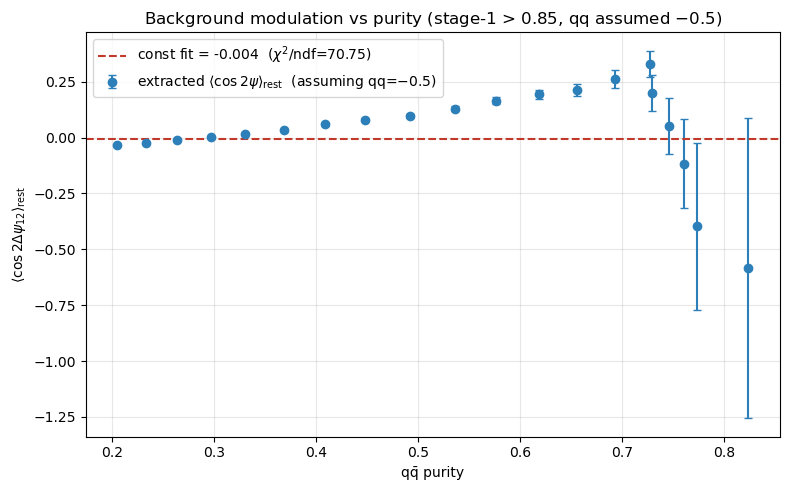

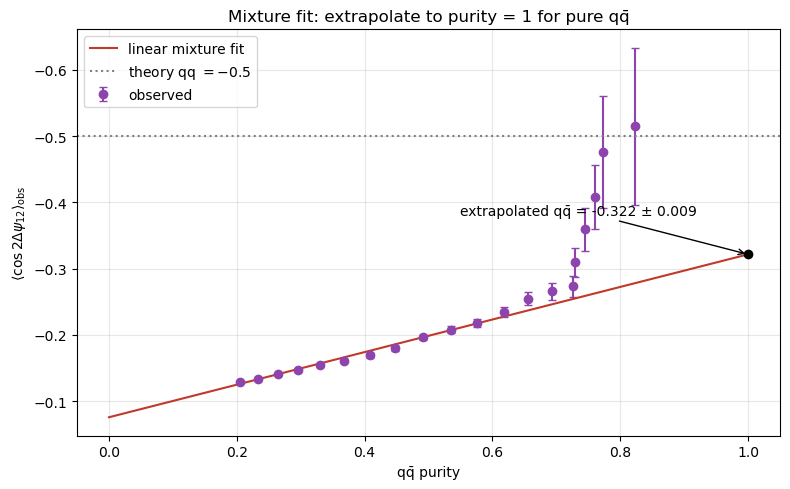

Extracted <cos2psi>_qqbar (p->1):  -0.3217 ± 0.0091
Extracted <cos2psi>_rest  (p->0):  -0.0758 ± 0.0041
(theory pure qqbar ~ -0.5;  compare above)


In [172]:
# --- inputs from the threshold scan (res) ---
p     = res["purity"].to_numpy()
obs   = res["cos2_mean"].to_numpy()
obs_e = res["cos2_err"].to_numpy()

# keep points with meaningful purity range and finite values
m = np.isfinite(p) & np.isfinite(obs) & (p > 0) & (p < 1)
p, obs, obs_e = p[m], obs[m], obs_e[m]

# ============================================================
# (A) Extract <cos2psi>_rest assuming <cos2psi>_qq = -0.5
# ============================================================
COS2_QQ = -0.5
rest = (obs - p*COS2_QQ) / (1.0 - p)
# error propagation: d(rest)/d(obs) = 1/(1-p)
rest_e = obs_e / (1.0 - p)

fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(p, rest, yerr=rest_e, fmt="o", color="#2c7fb8", capsize=3,
            label=r"extracted $\langle\cos2\psi\rangle_{\rm rest}$  (assuming qq=$-0.5$)")

# fit a constant to test flatness
w = 1.0/np.clip(rest_e,1e-6,None)**2
rest_const = np.sum(w*rest)/np.sum(w)
chi2 = np.sum(w*(rest - rest_const)**2)
ndf = len(rest) - 1
ax.axhline(rest_const, ls="--", color="#c0392b",
           label=f"const fit = {rest_const:+.3f}  ($\\chi^2$/ndf={chi2/ndf:.2f})")
ax.set_xlabel("qq̄ purity")
ax.set_ylabel(r"$\langle\cos2\Delta\psi_{12}\rangle_{\rm rest}$")
ax.set_title("Background modulation vs purity (stage-1 > 0.85, qq assumed $-0.5$)")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# ============================================================
# (B) The stronger version: fit the mixture line to EXTRACT qq
#     <cos2psi>_obs = B + p*(A - B)  -> straight line in p
#     intercept at p=1 is A = <cos2psi>_qq
# ============================================================
coef, cov = np.polyfit(p, obs, 1, w=1.0/np.clip(obs_e,1e-6,None), cov=True)
slope, intercept0 = coef                 # obs = slope*p + intercept0
A = slope*1.0 + intercept0               # value at p=1  -> qqbar
B = intercept0                           # value at p=0  -> rest
# uncertainties from covariance
dA = np.sqrt(cov[0,0] + cov[1,1] + 2*cov[0,1])   # var(slope+intercept)
dB = np.sqrt(cov[1,1])

fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(p, obs, yerr=obs_e, fmt="o", color="#8e44ad", capsize=3, label="observed")
pp = np.linspace(0, 1, 100)
ax.plot(pp, slope*pp + intercept0, "-", color="#c0392b",
        label="linear mixture fit")
ax.axhline(-0.5, ls=":", color="grey", label="theory qq $= -0.5$")
ax.scatter([1.0], [A], color="black", zorder=5)
ax.annotate(f"extrapolated qq̄ = {A:+.3f} ± {dA:.3f}",
            xy=(1.0, A), xytext=(0.55, A-0.06),
            arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("qq̄ purity")
ax.set_ylabel(r"$\langle\cos2\Delta\psi_{12}\rangle_{\rm obs}$")
ax.set_title("Mixture fit: extrapolate to purity = 1 for pure qq̄")
ax.grid(alpha=0.3); ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.show()

print(f"Extracted <cos2psi>_qqbar (p->1):  {A:+.4f} ± {dA:.4f}")
print(f"Extracted <cos2psi>_rest  (p->0):  {B:+.4f} ± {dB:.4f}")
print(f"(theory pure qqbar ~ -0.5;  compare above)")

True qqbar jets: 52601


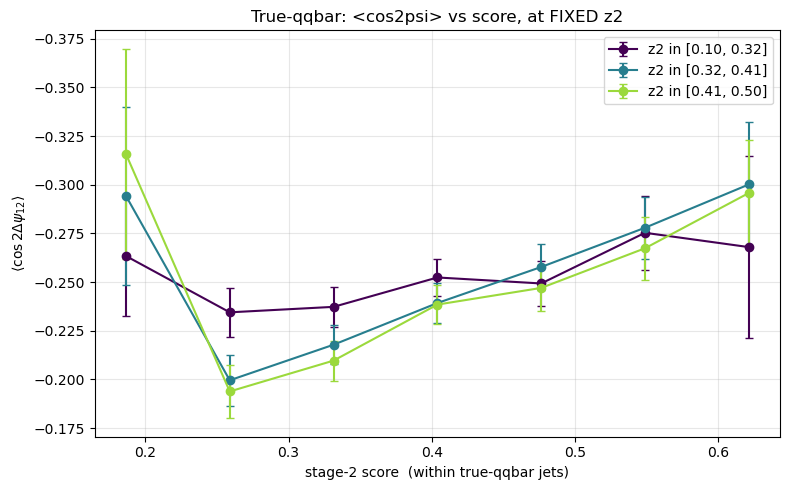

In [168]:
# ---- use ONLY true qqbar jets, so the flavour label is held fixed ----
qq = df2[df2["channel2"] == 1].copy()
print("True qqbar jets:", len(qq))

# kinematic variable to fix. z2 controls the secondary (g->qqbar) modulation,
# so bin in z2 (try z1 or z_min too).
KVAR = "z2"

# define z bins (quantiles so each has similar stats)
n_zbins = 3
qq["zbin"] = pd.qcut(qq[KVAR], n_zbins, labels=False, duplicates="drop")

# within each z-bin, scan the score and measure <cos2psi> of true-qqbar jets
score_edges = np.linspace(qq["score"].min(), qq["score"].max(), 9)
score_cent  = 0.5*(score_edges[:-1] + score_edges[1:])

fig, ax = plt.subplots(figsize=(8,5))
colors = plt.cm.viridis(np.linspace(0,0.85,n_zbins))

for zb in range(n_zbins):
    sub = qq[qq["zbin"] == zb]
    zlo, zhi = sub[KVAR].min(), sub[KVAR].max()
    xs, ys, es = [], [], []
    for lo, hi in zip(score_edges[:-1], score_edges[1:]):
        m = (sub["score"] >= lo) & (sub["score"] < hi)
        n = int(m.sum())
        if n < 50:               # need enough jets for a stable mean
            continue
        c = np.cos(2.0 * sub.loc[m, "dpsi12"].to_numpy())
        xs.append(0.5*(lo+hi)); ys.append(c.mean()); es.append(c.std()/np.sqrt(n))
    ax.errorbar(xs, ys, yerr=es, fmt="o-", color=colors[zb], capsize=3,
                label=f"{KVAR} in [{zlo:.2f}, {zhi:.2f}]")

ax.set_xlabel("stage-2 score  (within true-qqbar jets)")
ax.set_ylabel(r"$\langle\cos 2\Delta\psi_{12}\rangle$")
ax.set_title(f"True-qqbar: <cos2psi> vs score, at FIXED {KVAR}")
ax.grid(alpha=0.3); ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.show()

IFN qqbar label  <cos2psi> = -0.2388  (N=52,601)
Background qg+gg <cos2psi> = -0.1242  (N=375,500)


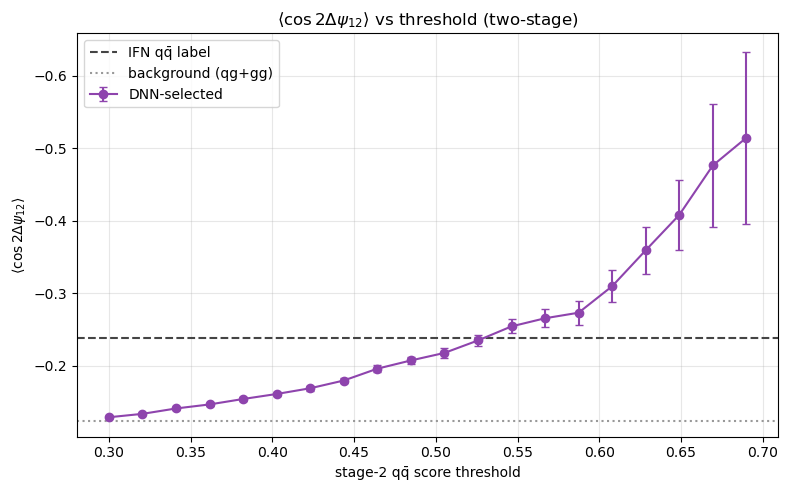

In [ ]:
cos2_qqbar = np.cos(2.0*dpsi[y_true==1]).mean()
cos2_bkg   = np.cos(2.0*dpsi[y_true==0]).mean()
print(f"IFN qqbar label  <cos2psi> = {cos2_qqbar:+.4f}  (N={int((y_true==1).sum()):,})")
print(f"Background qg+gg <cos2psi> = {cos2_bkg:+.4f}  (N={int((y_true==0).sum()):,})")

fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(res["threshold"], res["cos2_mean"], yerr=res["cos2_err"],
            fmt="o-", color="#8e44ad", capsize=3, label=r"DNN-selected")
ax.axhline(cos2_qqbar, ls="--", color="#444444", label="IFN qq̄ label")
ax.axhline(cos2_bkg,   ls=":",  color="#999999", label="background (qg+gg)")
ax.set_xlabel("stage-2 qq̄ score threshold")
ax.set_ylabel(r"$\langle \cos 2\Delta\psi_{12}\rangle$")
ax.set_title(r"$\langle\cos 2\Delta\psi_{12}\rangle$ vs threshold (two-stage)")
ax.grid(alpha=0.3); ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"cos2psi_vs_threshold.png", dpi=150); plt.show()

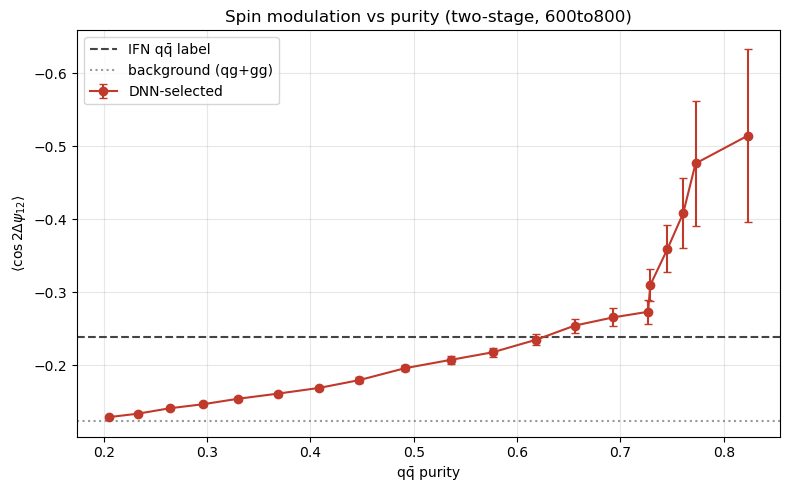

Saved figures + table to /Users/alexmendonca/Desktop/pic2/python/outputs_twostage_600to800


In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(res["purity"], res["cos2_mean"], yerr=res["cos2_err"],
            fmt="o-", color="#c0392b", capsize=3, label="DNN-selected")
ax.axhline(cos2_qqbar, ls="--", color="#444444", label="IFN qq̄ label")
ax.axhline(cos2_bkg,   ls=":",  color="#999999", label="background (qg+gg)")
ax.set_xlabel("qq̄ purity"); ax.set_ylabel(r"$\langle \cos 2\Delta\psi_{12}\rangle$")
ax.set_title("Spin modulation vs purity (two-stage, 600to800)")
ax.grid(alpha=0.3); ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"cos2psi_vs_purity.png", dpi=150); plt.show()

res.to_csv(OUTPUT_DIR/"twostage_threshold_scan.csv", index=False)
print("Saved figures + table to", OUTPUT_DIR.resolve())

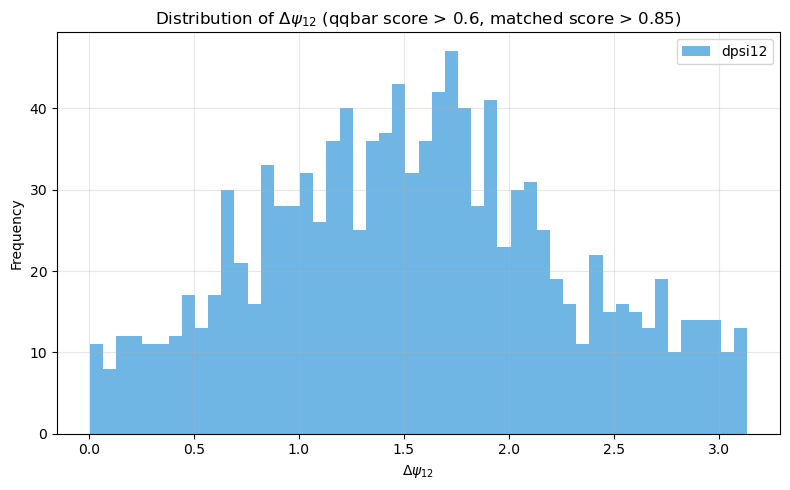

In [ ]:
# Filter data for the given thresholds
filtered_df = df2[(df2["score"] > 0.6) & (df2["stage1_matched_score"] > 0.85)]

# Plot the distribution of dpsi12
plt.figure(figsize=(8, 5))
plt.hist(filtered_df["dpsi12"], bins=50, color="#3498db", alpha=0.7, label="dpsi12")
plt.xlabel(r"$\Delta\psi_{12}$")
plt.ylabel("Frequency")
plt.title(r"Distribution of $\Delta\psi_{12}$ (qqbar score > 0.6, matched score > 0.85)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dpsi12_distribution.png", dpi=150)
plt.show()

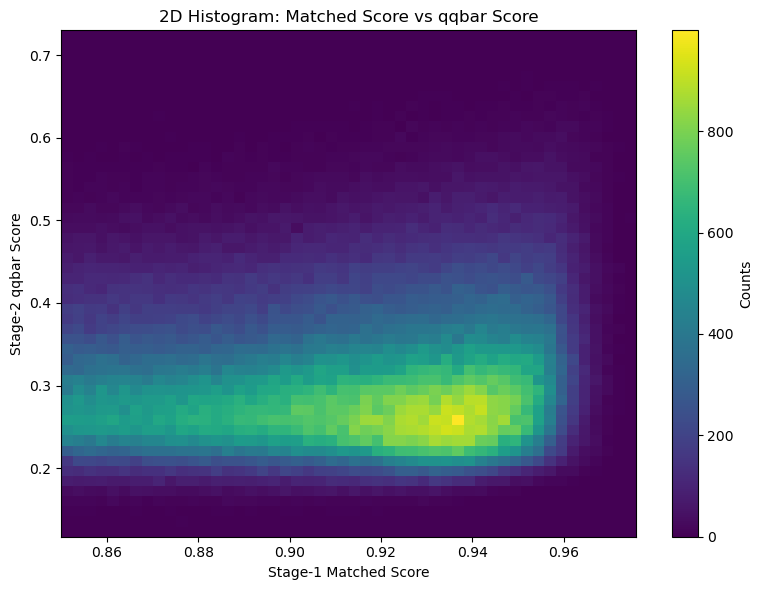

In [ ]:
# Create a 2D histogram of matched score vs qqbar score
plt.figure(figsize=(8, 6))
plt.hist2d(df2["stage1_matched_score"], df2["score"], bins=50, cmap="viridis")

# Add labels and title
plt.colorbar(label="Counts")
plt.xlabel("Stage-1 Matched Score")
plt.ylabel("Stage-2 qqbar Score")
plt.title("2D Histogram: Matched Score vs qqbar Score")

# Save and show the plot
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matched_vs_qqbar_score_2D_histogram.png", dpi=150)
plt.show()

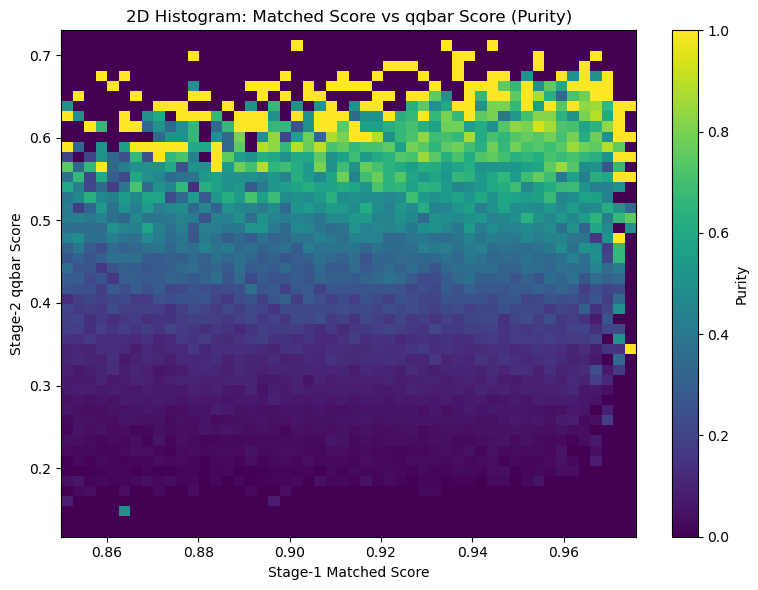

In [ ]:
# Define the bin edges
bins = 50
x_bins = np.linspace(df2["stage1_matched_score"].min(), df2["stage1_matched_score"].max(), bins + 1)
y_bins = np.linspace(df2["score"].min(), df2["score"].max(), bins + 1)

# Initialize arrays to store purity
purity = np.zeros((bins, bins))

# Loop through each bin and calculate purity
for i in range(bins):
    for j in range(bins):
        # Get the mask for events in the current bin
        mask = (
            (df2["stage1_matched_score"] >= x_bins[i]) & (df2["stage1_matched_score"] < x_bins[i + 1]) &
            (df2["score"] >= y_bins[j]) & (df2["score"] < y_bins[j + 1])
        )
        # Get the events in the bin
        bin_events = df2[mask]
        if len(bin_events) > 0:
            # Calculate purity as the fraction of true qqbar events
            purity[i, j] = (bin_events["is_qqbar"] == 1).mean()

# Plot the 2D histogram with purity
plt.figure(figsize=(8, 6))
plt.pcolormesh(x_bins, y_bins, purity.T, cmap="viridis", shading="auto")
plt.colorbar(label="Purity")
plt.xlabel("Stage-1 Matched Score")
plt.ylabel("Stage-2 qqbar Score")
plt.title("2D Histogram: Matched Score vs qqbar Score (Purity)")

# Save and show the plot
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matched_vs_qqbar_score_2D_purity.png", dpi=150)
plt.show()